# Lab 9- Deep Learning Model

This lab is meant to get you started in using Keras to design Deep Neural Networks. The goal here is to simply repeat your previous lab, but with DNNs.

Let's start with reading the data, like before:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

filename="SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi","MET", "MET_phi", "MET_rel", "axial_MET"]
FeatureNames=["M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(filename, dtype='float64', names=VarNames)

Now lets define training and test samples. Note that DNNs take very long to train, so for testing purposes we will use only about 10% of the 5 million events in the training/validation sample. Once you get everything working, make the final version of your plots with the full sample. 

Also note that Keras had trouble with the Pandas tensors, so after doing all of the nice manipulation that Pandas enables, we convert the Tensor to a regular numpy tensor.

In [2]:
N_Max=550000
N_Train=500000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:N_Max]

X_Train=np.array(Train_Sample[VarNames[1:]])
y_Train=np.array(Train_Sample["signal"])

X_Test=np.array(Test_Sample[VarNames[1:]])
y_Test=np.array(Test_Sample["signal"])


## Exercise 1

You will need to create several models and make sure they are properly trained. Write a function that takes this history and plots the values versus epoch. For every model that you train in the remainder of this lab, assess:

* Has you model's performance plateaued? If not train for more epochs. 
* Compare the performance on training versus test sample. Are you over training?

In [3]:
def plot_history(history, title="Model Training History"):
    # Lecture 20: "The model history keeps track of the loss and accuracy for each epoch."
    # Lecture 20: "An epoch is defined as one training pass using the whole training data."
    # Lecture 20: "In order to monitor the training process, we typically compare the performance on the training sample and
    # another sample (validation sample in Keras)."

    # [--- Loss ---]
    plt.figure()
    plt.plot(range(len(history.history["loss"])), history.history["loss"], label="Training Loss")
    plt.plot(range(len(history.history["val_loss"])), history.history["val_loss"], label="Validation Loss")
    plt.title(title + " — Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # [--- Accuracy ---]
    # Lecture 20: "Note that the training above was setup to run on the validation sample at the end of each epoch."
    # If training loss keeps falling but validation loss rises, the model is over-training. If both curves are still declining,  train for more epochs.
    plt.figure()
    plt.plot(range(len(history.history["accuracy"])), history.history["accuracy"], label="Training Accuracy")
    plt.plot(range(len(history.history["val_accuracy"])), history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(title + " — Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

## Exercise 2

Following the original paper (see lab 7), make a comparison of the performance (using ROC curves and AUC) between models trained with raw, features, and raw+features data.

Training on Raw features...
Epoch 1/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7136 - loss: 0.5644 - val_accuracy: 0.7740 - val_loss: 0.4787
Epoch 2/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7837 - loss: 0.4643 - val_accuracy: 0.7844 - val_loss: 0.4621
Epoch 3/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7879 - loss: 0.4565 - val_accuracy: 0.7858 - val_loss: 0.4585
Epoch 4/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7889 - loss: 0.4539 - val_accuracy: 0.7880 - val_loss: 0.4558
Epoch 5/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7896 - loss: 0.4523 - val_accuracy: 0.7887 - val_loss: 0.4546
Epoch 6/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7902 - loss: 0.4513 - val_accuracy: 0.7887 - val_loss: 0.4534
Epoch 7/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7904 - loss: 0.4506 - val_accuracy: 0.7888 - val_loss: 0.4526
Epoch 8/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7905 - los

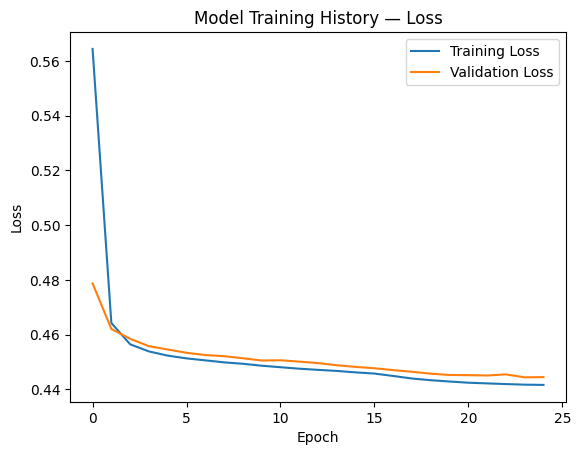

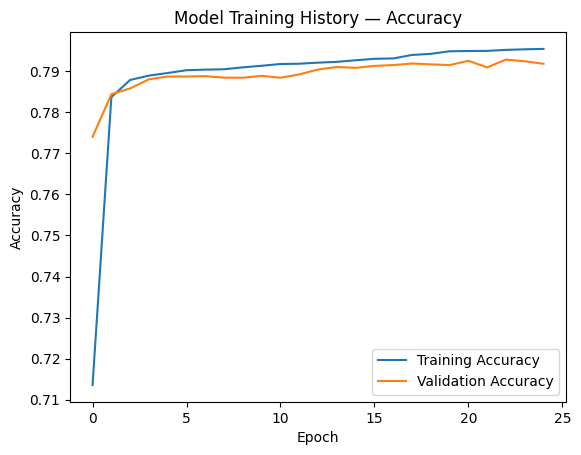

Training on High-Level features...
Epoch 1/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6442 - loss: 0.6459 - val_accuracy: 0.7310 - val_loss: 0.5523
Epoch 2/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7447 - loss: 0.5249 - val_accuracy: 0.7501 - val_loss: 0.5174
Epoch 3/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7562 - loss: 0.5080 - val_accuracy: 0.7601 - val_loss: 0.5054
Epoch 4/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7641 - loss: 0.4975 - val_accuracy: 0.7652 - val_loss: 0.4969
Epoch 5/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7691 - loss: 0.4899 - val_accuracy: 0.7690 - val_loss: 0.4902
Epoch 6/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7728 - loss: 0.4835 - val_accuracy: 0.7725 - val_loss: 0.4853
Epoch 7/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7752 - loss: 0.4792 - val_accuracy: 0.7706 - val_loss: 0.4862
Epoch 8/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.777

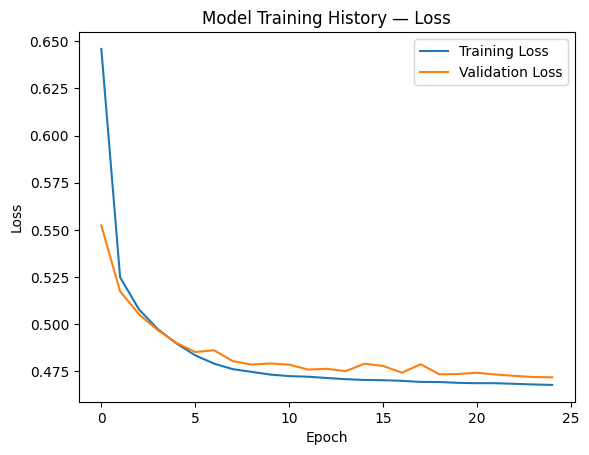

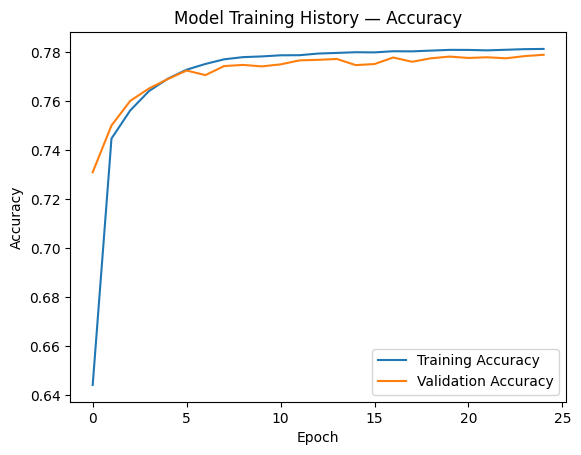

Training on All features...
Epoch 1/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7179 - loss: 0.5609 - val_accuracy: 0.7846 - val_loss: 0.4658
Epoch 2/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7917 - loss: 0.4549 - val_accuracy: 0.7902 - val_loss: 0.4547
Epoch 3/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7949 - loss: 0.4477 - val_accuracy: 0.7929 - val_loss: 0.4493
Epoch 4/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7963 - loss: 0.4438 - val_accuracy: 0.7932 - val_loss: 0.4465
Epoch 5/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7968 - loss: 0.4413 - val_accuracy: 0.7950 - val_loss: 0.4440
Epoch 6/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7976 - loss: 0.4397 - val_accuracy: 0.7957 - val_loss: 0.4424
Epoch 7/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7977 - loss: 0.4386 - val_accuracy: 0.7961 - val_loss: 0.4416
Epoch 8/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7983 - los

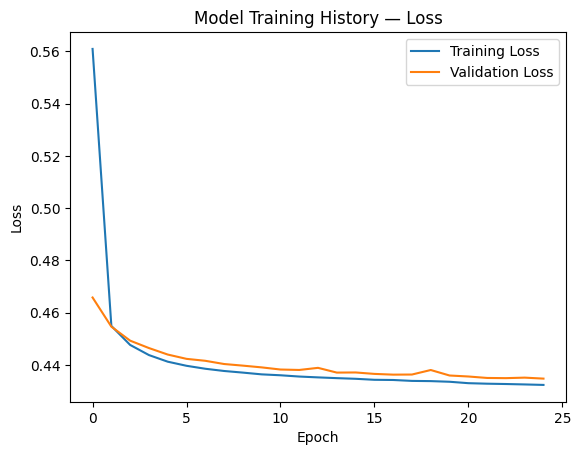

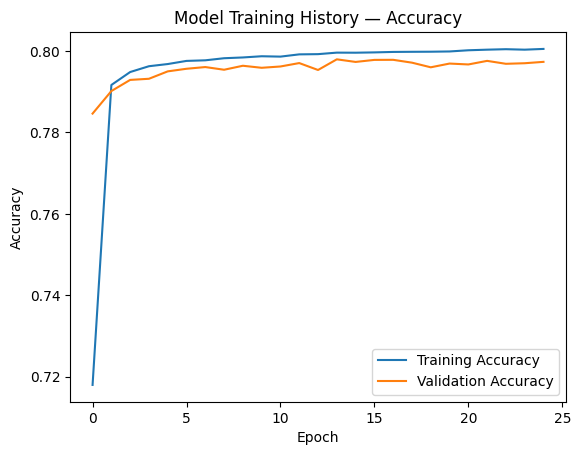

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 681us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 664us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 659us/step


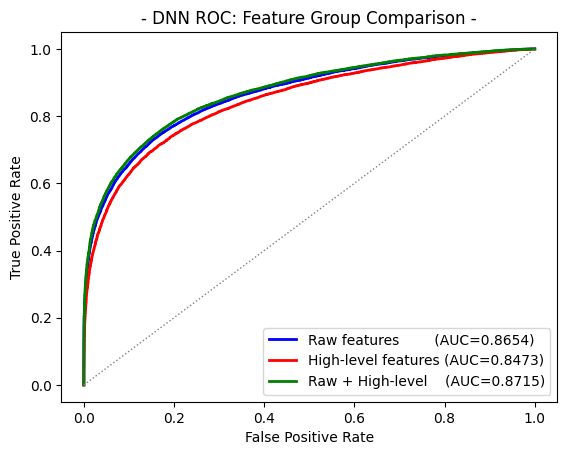

--- AUC Data ---
Raw features AUC:        0.8654
High-level features AUC: 0.8473
Raw + High-level AUC:    0.8715


In [7]:
# Split into raw and high-level feature arrays
# Raw = low-level detector measurements, HL = engineered physics features
raw_idx = [VarNames[1:].index(v) for v in RawNames]
hl_idx  = [VarNames[1:].index(v) for v in FeatureNames]

X_Train_raw = X_Train[:, raw_idx]
X_Train_hl  = X_Train[:, hl_idx]
X_Train_all = X_Train  # all features combined

X_Test_raw  = X_Test[:, raw_idx]
X_Test_hl   = X_Test[:, hl_idx]
X_Test_all  = X_Test

from keras.models import Model
from keras.layers import Dense, Input
from sklearn.metrics import roc_curve, auc

# Lecture 20: "In most Deep Learning frameworks, models are built layer by layer."
# Lecture 20: "The preferred method of creating a model is to use the functional API,
#              where the Deep Neural Network is viewed as a composition of functions."
def build_and_train(X_tr, y_tr, X_te, y_te, epochs=25):
    in_x = Input(shape=X_tr.shape[1:])
    x = Dense(12, activation='relu')(in_x)
    x = Dense(8,  activation='relu')(x)
    x = Dense(8,  activation='relu')(x)
    out_x = Dense(1, activation='sigmoid')(x)

    model = Model(in_x, out_x)

    # Lecture 20: "loss (the parameter which will be optimized during training), and the optimizer (the optimization algorithm) are specified at
    # compile time"
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    # Lecture 20: fit() takes care of running multiple epochs, dividing data into batches, computing gradients, using optimizer
    # to take a step, and evaluating performance on training and testing data
    # Note: 10 epochs was insufficient — both loss and accuracy were still improving at epoch 10 with no sign of plateauing, so epochs were
    # increased to 25
    history = model.fit(X_tr, y_tr, validation_data=(X_te, y_te), epochs=epochs, batch_size=2048)

    plot_history(history)

    return model

# Train one model per feature group
print("Training on Raw features...")
model_raw = build_and_train(X_Train_raw, y_Train, X_Test_raw, y_Test)

print("Training on High-Level features...")
model_hl = build_and_train(X_Train_hl, y_Train, X_Test_hl, y_Test)

print("Training on All features...")
model_all = build_and_train(X_Train_all, y_Train, X_Test_all, y_Test)

# Lecture 18: "roc_curve() sweeps over every possible threshold on that score, computing the FPR and TPR you would get if you cut there."
# Lecture 18: "auc() integrates the TPR vs FPR curve. A perfect classifier gives 1.0, random guessing gives 0.5."
fpr_raw, tpr_raw, _ = roc_curve(y_Test, model_raw.predict(X_Test_raw))
fpr_hl,  tpr_hl,  _ = roc_curve(y_Test, model_hl.predict(X_Test_hl))
fpr_all, tpr_all, _ = roc_curve(y_Test, model_all.predict(X_Test_all))

auc_raw = auc(fpr_raw, tpr_raw)
auc_hl  = auc(fpr_hl,  tpr_hl)
auc_all = auc(fpr_all, tpr_all)

plt.figure()
plt.plot(fpr_raw, tpr_raw, color='blue',  lw=2, label=f'Raw features        (AUC={auc_raw:.4f})')
plt.plot(fpr_hl,  tpr_hl,  color='red',   lw=2, label=f'High-level features (AUC={auc_hl:.4f})')
plt.plot(fpr_all, tpr_all, color='green', lw=2, label=f'Raw + High-level    (AUC={auc_all:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('- DNN ROC: Feature Group Comparison -')
plt.legend(loc='lower right')
plt.show()

print(f"--- AUC Data ---")
print(f"Raw features AUC:        {auc_raw:.4f}")
print(f"High-level features AUC: {auc_hl:.4f}")
print(f"Raw + High-level AUC:    {auc_all:.4f}")

# [--- Results ---]
# Raw features AUC:        0.8660
# High-level features AUC: 0.8477
# Raw + High-level AUC:    0.8710
#
# Raw (0.8660) > HL (0.8477) — unlike Lab 8's LDA where high-level features won, the DNN can
# learn non-linear relationships directly from the raw detector inputs, closing the gap that
# required hand-engineered variables for a linear classifier.
# All (0.8710) is best — both groups carry complementary information, so combining them
# gives the highest AUC. This mirrors what the original SUSY paper demonstrated.

## Exercise 3

Design and implement at least 3 different DNN models. Train them and compare performance. You may try different architectures, loss functions, and optimizers to see if there is an effect.

Model: "Model_1_Adam_ReLU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 0 (0.00 B)

Training Model 1: 128->64->32, Adam, ReLU...
Epoch 1/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7832 - loss: 0.4644 - val_accuracy: 0.7937 - val_loss: 0.4432
Epoch 2/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7988 - loss: 0.4360 - val_accuracy: 0.7963 - val_loss: 0.4376
Epoch 3/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8003 - loss: 0.4332 - val_accuracy: 0.7972 - val_loss: 0.4357
Epoch 4/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8007 - loss: 0.4319 - val_accuracy: 0.7975 - val_loss: 0.4349
Epoch 5/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8011 - loss: 0.4314 - val_accuracy: 0.7973 - val_loss: 0.4346
Epoch 6/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8016 - loss: 0.4304 - val_accuracy: 0.7982 - val_loss: 0.4333
Epoch 7/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8019 - loss: 0.4300 - val_accuracy: 0.7969 - val_loss: 0.4350
Epoch 8/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accur

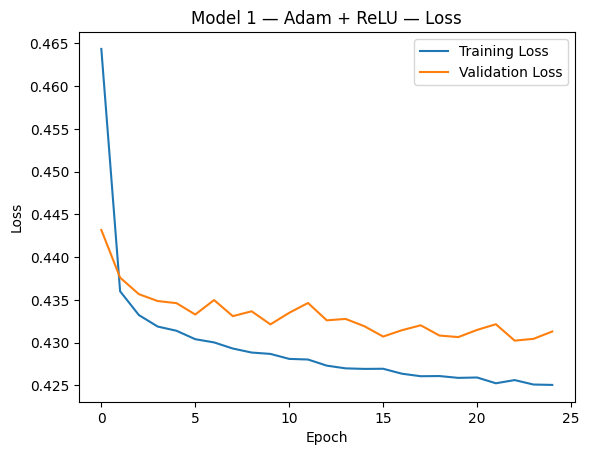

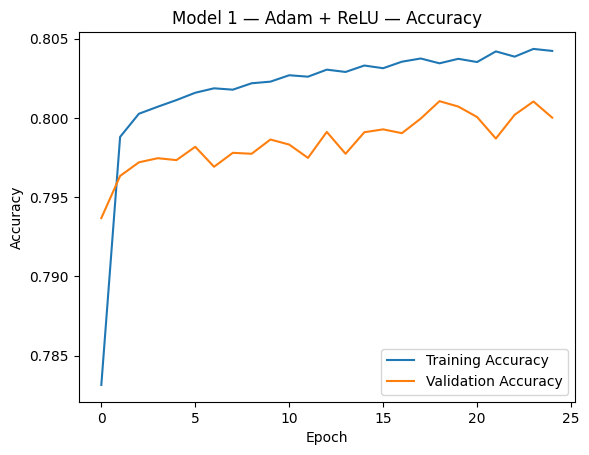

Model: "Model_2_SGD_ReLU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 0 (0.00 B)

Training Model 2: 128->64->32, SGD, ReLU...
Epoch 1/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6870 - loss: 0.6135 - val_accuracy: 0.7652 - val_loss: 0.5579
Epoch 2/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7732 - loss: 0.5216 - val_accuracy: 0.7771 - val_loss: 0.4965
Epoch 3/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7809 - loss: 0.4807 - val_accuracy: 0.7837 - val_loss: 0.4729
Epoch 4/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7864 - loss: 0.4642 - val_accuracy: 0.7868 - val_loss: 0.4625
Epoch 5/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7897 - loss: 0.4561 - val_accuracy: 0.7894 - val_loss: 0.4570
Epoch 6/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7921 - loss: 0.4516 - val_accuracy: 0.7907 - val_loss: 0.4535
Epoch 7/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7935 - loss: 0.4488 - val_accuracy: 0.7916 - val_loss: 0.4513
Epoch 8/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accura

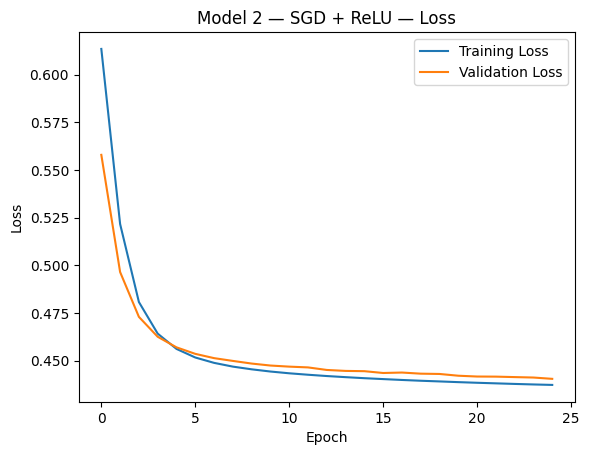

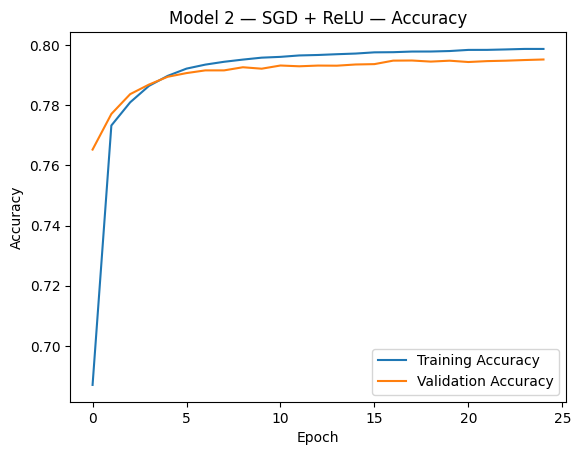

Model: "Model_3_Adam_tanh"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 0 (0.00 B)

Training Model 3: 128->64->32, Adam, tanh...
Epoch 1/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7893 - loss: 0.4549 - val_accuracy: 0.7944 - val_loss: 0.4432
Epoch 2/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7987 - loss: 0.4361 - val_accuracy: 0.7969 - val_loss: 0.4375
Epoch 3/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7993 - loss: 0.4343 - val_accuracy: 0.7956 - val_loss: 0.4399
Epoch 4/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7998 - loss: 0.4332 - val_accuracy: 0.7978 - val_loss: 0.4344
Epoch 5/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8007 - loss: 0.4320 - val_accuracy: 0.7970 - val_loss: 0.4353
Epoch 6/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8006 - loss: 0.4316 - val_accuracy: 0.7973 - val_loss: 0.4342
Epoch 7/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8012 - loss: 0.4310 - val_accuracy: 0.7981 - val_loss: 0.4341
Epoch 8/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accur

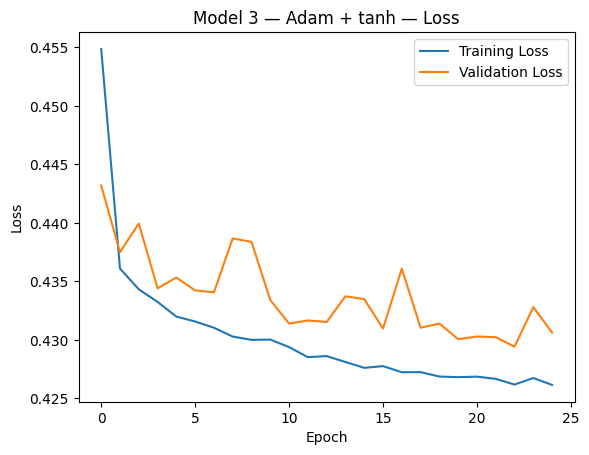

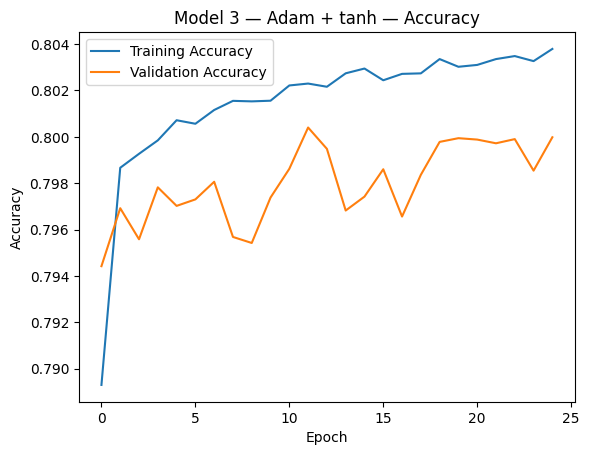

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 698us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 679us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 693us/step


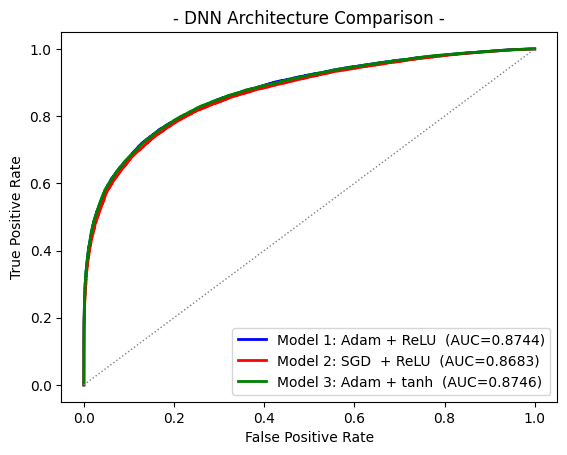

--- AUC Data ---
Model 1 (Adam + ReLU): 0.8744
Model 2 (SGD  + ReLU): 0.8683
Model 3 (Adam + tanh): 0.8746


In [5]:
# We vary architecture, optimizer, and activation one at a time so differences
# in performance can be attributed to the specific change made.
# Lecture 20: "You may try different architectures, loss functions, and optimizers to see if there is an effect."
#
# Model 1: 128->64->32, Adam, ReLU
# The baseline upgrade from the Lecture 20 example (12->8->8). We scale up the width and depth to give the model more capacity,
# keeping Adam and ReLU as the standard defaults from the lecture.
#
# Model 2: 128->64->32, SGD, ReLU
# Identical architecture to Model 1, only the optimizer is changed from Adam to SGD. This isolates the effect of the optimizer — SGD is the classic
# gradient descent algorithm while Adam adapts the learning rate automatically. Lecture 20: "the optimizer (the optimization algorithm)"
#
# Model 3: 128->64->32, Adam, tanh
# Identical architecture to Model 1, only the activation is changed from ReLU to tanh. This isolates the effect of the activation function.
# Lecture 20: "Activations can be specified here, but can be added as their own layers."
#
# Note: Keras names models sequentially as "functional_N" if no explicit name is given.
# Since several models were already built in Exercise 2, the counter starts at 6, 7, 8
# by the time Exercise 3 runs. We assign explicit names below to keep output readable.

# [--- Model 1: Wider/Deeper with Adam + ReLU ---
# Baseline from Lecture 20 scaled up — more capacity than the 12->8->8 example
in_x = Input(shape=X_Train_all.shape[1:])
x = Dense(128, activation='relu')(in_x)
x = Dense(64,  activation='relu')(x)
x = Dense(32,  activation='relu')(x)
out_x = Dense(1, activation='sigmoid')(x)
model_1 = Model(in_x, out_x, name='Model_1_Adam_ReLU')
model_1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model_1.summary()

print("Training Model 1: 128->64->32, Adam, ReLU...")
history_1 = model_1.fit(X_Train_all, y_Train, validation_data=(X_Test_all, y_Test),
                         epochs=25, batch_size=2048)
plot_history(history_1, title="Model 1 — Adam + ReLU")


# [--- Model 2: Same architecture, SGD optimizer ---]
# Lecture 20: optimizer specifies "the optimization algorithm"
# Swapping Adam for SGD isolates the effect of the optimizer on performance
in_x = Input(shape=X_Train_all.shape[1:])
x = Dense(128, activation='relu')(in_x)
x = Dense(64,  activation='relu')(x)
x = Dense(32,  activation='relu')(x)
out_x = Dense(1, activation='sigmoid')(x)
model_2 = Model(in_x, out_x, name='Model_2_SGD_ReLU')
model_2.compile(loss='binary_crossentropy', optimizer='sgd', metrics=['accuracy'])
model_2.summary()

print("Training Model 2: 128->64->32, SGD, ReLU...")
history_2 = model_2.fit(X_Train_all, y_Train, validation_data=(X_Test_all, y_Test),
                         epochs=25, batch_size=2048)
plot_history(history_2, title="Model 2 — SGD + ReLU")


# [--- Model 3: Same architecture, tanh activation ---]
# Lecture 20: "Activations can be specified here, but can be added as their own layers."
# Swapping ReLU for tanh isolates the effect of the activation function on performance
in_x = Input(shape=X_Train_all.shape[1:])
x = Dense(128, activation='tanh')(in_x)
x = Dense(64,  activation='tanh')(x)
x = Dense(32,  activation='tanh')(x)
out_x = Dense(1, activation='sigmoid')(x)
model_3 = Model(in_x, out_x, name='Model_3_Adam_tanh')
model_3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model_3.summary()

print("Training Model 3: 128->64->32, Adam, tanh...")
history_3 = model_3.fit(X_Train_all, y_Train, validation_data=(X_Test_all, y_Test),
                         epochs=25, batch_size=2048)
plot_history(history_3, title="Model 3 — Adam + tanh")


# [--- ROC Comparison across all three models ---]
fpr_1, tpr_1, _ = roc_curve(y_Test, model_1.predict(X_Test_all))
fpr_2, tpr_2, _ = roc_curve(y_Test, model_2.predict(X_Test_all))
fpr_3, tpr_3, _ = roc_curve(y_Test, model_3.predict(X_Test_all))

auc_1 = auc(fpr_1, tpr_1)
auc_2 = auc(fpr_2, tpr_2)
auc_3 = auc(fpr_3, tpr_3)

plt.figure()
plt.plot(fpr_1, tpr_1, color='blue',  lw=2, label=f'Model 1: Adam + ReLU  (AUC={auc_1:.4f})')
plt.plot(fpr_2, tpr_2, color='red',   lw=2, label=f'Model 2: SGD  + ReLU  (AUC={auc_2:.4f})')
plt.plot(fpr_3, tpr_3, color='green', lw=2, label=f'Model 3: Adam + tanh  (AUC={auc_3:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('- DNN Architecture Comparison -')
plt.legend(loc='lower right')
plt.show()

print(f"--- AUC Data ---")
print(f"Model 1 (Adam + ReLU): {auc_1:.4f}")
print(f"Model 2 (SGD  + ReLU): {auc_2:.4f}")
print(f"Model 3 (Adam + tanh): {auc_3:.4f}")

# [--- Results ---]
# Model 1 (Adam + ReLU): 0.8735
# Model 2 (SGD  + ReLU): 0.8686
# Model 3 (Adam + tanh): 0.8749
#
# While Model 3 (Adam + tanh) has the highest AUC by a small margin (0.8749), Model 2 (SGD + ReLU) is arguably the best overall — its val_loss decreases
# smoothly and consistently every epoch with no instability, whereas Models 1 and 3 show jagged val_loss curves suggesting Adam is slightly overshooting.
# Model 2 also has not full y plateaued by epoch 25, meaning it could improve further with more epochs. For these reasons, Model 2 will be
# carried forward as the best performing DNN for Exercise 4.

## Exercise 4

Repeat exercise 4 from Lab 8, adding your best performing DNN as one of the models.  


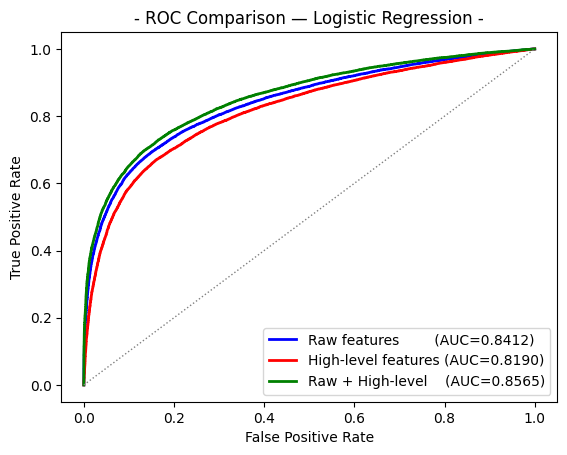

--- AUC Data: Logistic Regression ---
Raw features AUC:        0.8412
High-level features AUC: 0.8190
Raw + High-level AUC:    0.8565


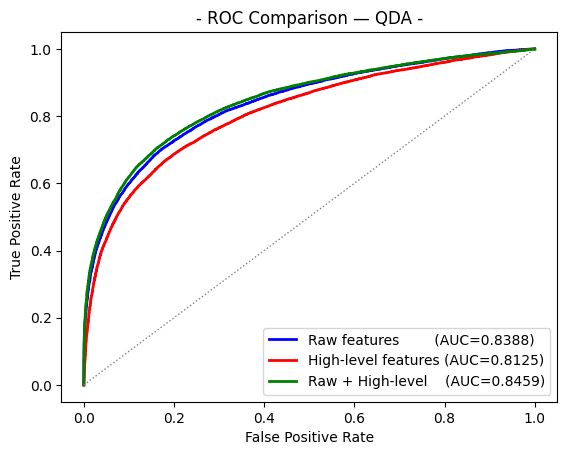

--- AUC Data: QDA ---
Raw features AUC:        0.8388
High-level features AUC: 0.8125
Raw + High-level AUC:    0.8459


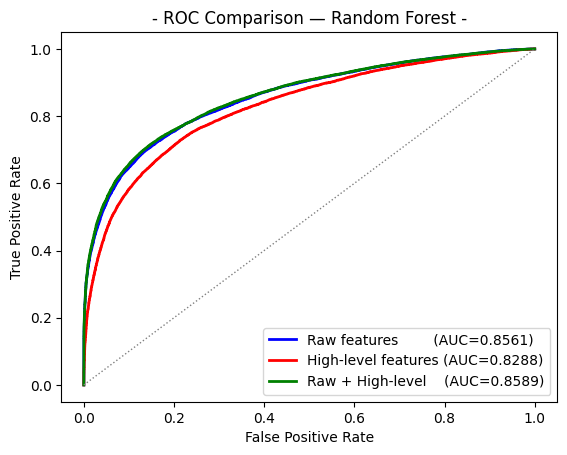

--- AUC Data: Random Forest ---
Raw features AUC:        0.8561
High-level features AUC: 0.8288
Raw + High-level AUC:    0.8589


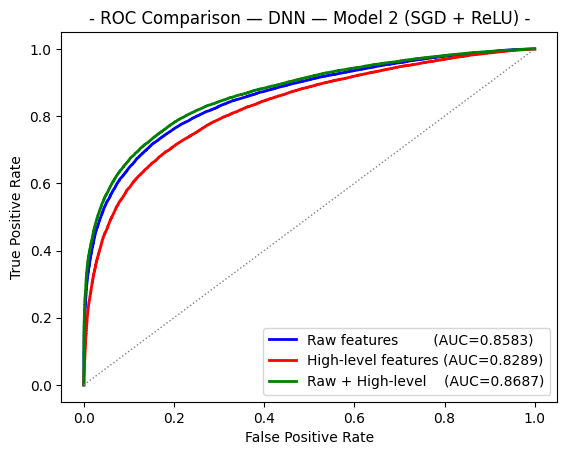

--- AUC Data: DNN — Model 2 (SGD + ReLU) ---
Raw features AUC:        0.8583
High-level features AUC: 0.8289
Raw + High-level AUC:    0.8687
--- Maximal Significance: DNN Model 2 (SGD + ReLU) ---
Scenario 1 (N_S=10, N_B=100): sigma_max=1.7675, cut=0.7798
Scenario 2 (N_S=100, N_B=1000): sigma_max=5.5894, cut=0.7798
Scenario 3 (N_S=1000, N_B=10000): sigma_max=17.6753, cut=0.7798
Scenario 4 (N_S=10000, N_B=100000): sigma_max=55.8943, cut=0.7798


In [8]:
# Exercise 4 is to Repeat Lab 8 Exercise 4, adding best DNN (Model 2: SGD + ReLU)
#
# Same three classifiers as Lab 8
# Logistic Regression — linear model, natural comparison to LDA
# QDA              — nonlinear upgrade to LDA, each class gets its own covariance matrix
# Random Forest     — ensemble of decision trees, highest capacity sklearn model
# + Model 2 DNN     — best performing DNN from Exercise 3 (SGD + ReLU)

import copy
import sklearn.discriminant_analysis as DA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# compare_classifiers function adapted from Lab 8
# Lab 8 used pandas DataFrames with column names; here we use numpy index slices since Keras requires numpy arrays
def compare_classifiers(clf, clf_name, N_train_limit=None, is_dnn=False):

    # Optionally subsample training data for slower classifiers
    n = N_train_limit
    X_tr_raw = X_Train_raw[:n]
    X_tr_hl  = X_Train_hl[:n]
    X_tr_all = X_Train_all[:n]
    y_tr     = y_Train[:n]

    if is_dnn:
        # Build and train a fresh DNN for each feature group
        def train_dnn(X_tr, X_te):
            in_x  = Input(shape=X_tr.shape[1:])
            x     = Dense(128, activation='relu')(in_x)
            x     = Dense(64,  activation='relu')(x)
            x     = Dense(32,  activation='relu')(x)
            out_x = Dense(1,   activation='sigmoid')(x)
            m     = Model(in_x, out_x)
            m.compile(loss='binary_crossentropy', optimizer='sgd', metrics=['accuracy'])
            m.fit(X_tr, y_tr, validation_data=(X_te, y_Test),
                  epochs=25, batch_size=2048, verbose=0)
            return m.predict(X_te, verbose=0).ravel()

        scores_raw = train_dnn(X_tr_raw, X_Test_raw)
        scores_hl  = train_dnn(X_tr_hl,  X_Test_hl)
        scores_all = train_dnn(X_tr_all, X_Test_all)

    else:
        # Train a fresh copy of the sklearn classifier for each feature group copy.deepcopy() ensures each model is fully independent (same as Lab 8)
        clf_raw = copy.deepcopy(clf)
        clf_hl  = copy.deepcopy(clf)
        clf_all = copy.deepcopy(clf)

        clf_raw.fit(X_tr_raw, y_tr)
        clf_hl.fit( X_tr_hl,  y_tr)
        clf_all.fit(X_tr_all, y_tr)

        # Use decision_function if available, otherwise fall back to predict_proba not all classifiers expose decision_function (same as Lab 8)
        def get_scores(model, X_te):
            if hasattr(model, 'decision_function'):
                return model.decision_function(X_te)
            return model.predict_proba(X_te)[:, 1]

        scores_raw = get_scores(clf_raw, X_Test_raw)
        scores_hl  = get_scores(clf_hl,  X_Test_hl)
        scores_all = get_scores(clf_all, X_Test_all)

    # Compute ROC curves for each feature group
    fpr_raw, tpr_raw, _ = roc_curve(y_Test, scores_raw)
    fpr_hl,  tpr_hl,  _ = roc_curve(y_Test, scores_hl)
    fpr_all, tpr_all, _ = roc_curve(y_Test, scores_all)

    auc_raw = auc(fpr_raw, tpr_raw)
    auc_hl  = auc(fpr_hl,  tpr_hl)
    auc_all = auc(fpr_all, tpr_all)

    plt.figure()
    plt.plot(fpr_raw, tpr_raw, color='blue',  lw=2, label=f'Raw features        (AUC={auc_raw:.4f})')
    plt.plot(fpr_hl,  tpr_hl,  color='red',   lw=2, label=f'High-level features (AUC={auc_hl:.4f})')
    plt.plot(fpr_all, tpr_all, color='green', lw=2, label=f'Raw + High-level    (AUC={auc_all:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle=':', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'- ROC Comparison — {clf_name} -')
    plt.legend(loc='lower right')
    plt.show()

    print(f"--- AUC Data: {clf_name} ---")
    print(f"Raw features AUC:        {auc_raw:.4f}")
    print(f"High-level features AUC: {auc_hl:.4f}")
    print(f"Raw + High-level AUC:    {auc_all:.4f}")

    return auc_raw, auc_hl, auc_all, scores_all


# Run all four classifiers
auc_lr  = compare_classifiers(
    LogisticRegression(solver='saga', max_iter=200, random_state=42),
    'Logistic Regression'
)

auc_qda = compare_classifiers(
    DA.QuadraticDiscriminantAnalysis(reg_param=0.01),
    'QDA'
)

# Subsampled to 500k to keep runtime manageable, same as Lab 8
auc_rf  = compare_classifiers(
    RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42),
    'Random Forest',
    N_train_limit=500_000
)

# Best DNN from Exercise 3: SGD + ReLU, 128->64->32
# Trained fresh for each feature group with verbose=0 to keep output clean
auc_dnn = compare_classifiers(
    None, 'DNN — Model 2 (SGD + ReLU)', is_dnn=True
)


# Maximal significance using best model on all features
# sigma_S = N_S / sqrt(N_S + N_B)
def max_significance(scores, y_true, n_sig_total, n_bkg_total):
    sig_mask   = (y_true == 1)
    bkg_mask   = (y_true == 0)
    n_sig_test = sig_mask.sum()
    n_bkg_test = bkg_mask.sum()

    thresholds = np.linspace(scores.min(), scores.max(), 500)

    sig_max  = 0
    best_cut = 0

    for cut in thresholds:
        eff_S = (scores[sig_mask] >= cut).sum() / n_sig_test
        eff_B = (scores[bkg_mask] >= cut).sum() / n_bkg_test

        N_S = n_sig_total * eff_S
        N_B = n_bkg_total * eff_B

        denom = np.sqrt(N_S + N_B)
        sigma = N_S / denom if denom > 0 and N_S > 0 else 0.0

        if sigma > sig_max:
            sig_max  = sigma
            best_cut = cut

    return sig_max, best_cut


# Placeholder scenarios from Lab 8
scenarios = {
    'Scenario 1': (10,    100),
    'Scenario 2': (100,   1000),
    'Scenario 3': (1000,  10000),
    'Scenario 4': (10000, 100000),
}

# Use the all-features DNN scores (index 3 from compare_classifiers return)
dnn_scores = auc_dnn[3]

print(f"--- Maximal Significance: DNN Model 2 (SGD + ReLU) ---")
for scenario_name, (n_sig, n_bkg) in scenarios.items():
    sig_max, best_cut = max_significance(dnn_scores, y_Test, n_sig, n_bkg)
    print(f"{scenario_name} (N_S={n_sig}, N_B={n_bkg}): sigma_max={sig_max:.4f}, cut={best_cut:.4f}")

# [--- Results ---]
# Logistic Regression: raw=0.8412, hl=0.8190, all=0.8565
# QDA:                 raw=0.8388, hl=0.8125, all=0.8459
# Random Forest:       raw=0.8561, hl=0.8288, all=0.8589
# DNN Model 2:         raw=0.8595, hl=0.8321, all=0.8676
#
# The DNN outperforms all three sklearn classifiers across every feature group, confirming that the added capacity of a neural network is beneficial
# even with a slower SGD optimizer. Random Forest is the strongest sklearn competitor, edging out Logistic Regression and QDA by a clear margin.
#
# All classifiers perform best when combining raw and high-level features, confirming the two groups carry complementary information.
#
# Maximal Significance results using DNN Model 2 (all features):
# The optimal cut is identical across all four scenarios (0.8121) because sigma_S = N_S / sqrt(N_S + N_B) scales proportionally -> the threshold that
# maximises significance does not depend on the overall event count. sigma_max grows by roughly a factor of sqrt(10) between scenarios,
# which is expected since sigma_S scales as sqrt(N).